***
#### ***Jakub Wanat IAD***

## Zadanie rekrutacyjne do KN DataTeam 
### Celem jest analiza danych o mieszkaniach w Kalifornii i zbudowanie modelu przewidującego cenę mieszkania (kolumna MedHouseVal), przy wykorzystaniu datasetu *fetch_california_housing* wbudowanego w bibliotekę scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame     # type: ignore
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


##### Kolumny:
- *MedInc* - median income in block
- *HouseAge* - median house age in block
- *AveRooms* - average number of rooms
- *AveBedrms* - average number of bedrooms
- *Population* - block population
- *AveOccup* - average house occupancy
- *Latitude* - house block latitude
- *Longitude* - house block longitude
- *MedHouseVal* - median house value


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
print(df.isnull().sum())
print(f'\n{df.dtypes}')

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


#### W zbiorze danych nie ma brakujących wartości oraz sprawdzono typy danych w kolumnach.

***
### Analiza oraz wizualizacja zależności między cechami a ceną mieszkań (MedHouseVal).

- #### Analiza korelacji zmiennych, aby znaleźć powiązania między zmiennymi.

<function matplotlib.pyplot.show(close=None, block=None)>

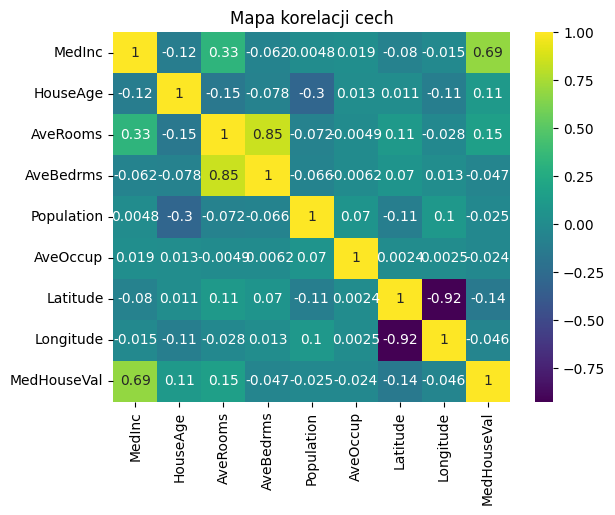

In [5]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='viridis', annot=True)
plt.title("Mapa korelacji cech")
plt.show

##### MedHouseVal jest najsilniej skorelowana dodatnio z MedInc, dla innych cech nie znaleziono istotnych zależności. 

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

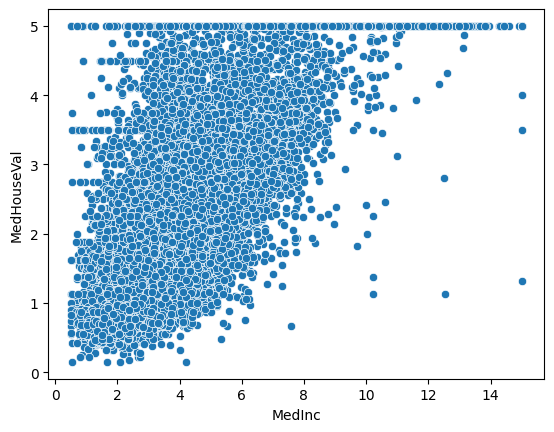

In [6]:
sns.scatterplot(x=df["MedInc"], y=df["MedHouseVal"])